#📌 Extracción

In [93]:
import pandas as pd
import requests

In [94]:
url='https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
#pd.read_json(url)
#usando requests
response= requests.get(url)
data = response.json()

df= pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [95]:
df = pd.json_normalize(data)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

**Verifición**

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [97]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


**Verificacion valores unicos**

In [98]:
for col in df.columns:
  #print(f"Valores unicos en la columna '{col}': {df[col].unique()}")
  print(f"Valores unicos en la columna '{col}: {df[col].nunique()}'")

  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-'*50)

Valores unicos en la columna 'customerID: 7267'
Valores unicos en la columna 'Churn: 3'
['No' 'Yes' '']
--------------------------------------------------
Valores unicos en la columna 'customer.gender: 2'
['Female' 'Male']
--------------------------------------------------
Valores unicos en la columna 'customer.SeniorCitizen: 2'
[0 1]
--------------------------------------------------
Valores unicos en la columna 'customer.Partner: 2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna 'customer.Dependents: 2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna 'customer.tenure: 73'
Valores unicos en la columna 'phone.PhoneService: 2'
['Yes' 'No']
--------------------------------------------------
Valores unicos en la columna 'phone.MultipleLines: 3'
['No' 'Yes' 'No phone service']
--------------------------------------------------
Valores unicos en la columna 'internet.InternetService: 3'
['DSL' 'Fiber o

**Valores Duplicados**

In [99]:
print("Numeros duplicados",df.duplicated().sum())

Numeros duplicados 0


**Valores nulos**

In [100]:
print("Numero de Nulos o NaN \n",df.isnull().sum())

Numero de Nulos o NaN 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


**Valores Vacios o en blanco**

In [101]:
df.apply(lambda x: x.astype(str).str.strip()=='').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


**Transformar**

Cambiando la columna **account.Charges.Total** a float

In [102]:
#prueba = df['account.Charges.Total'].astype(np.float) no se usa el numpy
df['account.Charges.Total'] = df['account.Charges.Total'].apply(pd.to_numeric,errors='coerce') #coerce convierte valores vacios a nulos
print(df['account.Charges.Total'].dtype)
#

float64


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

Eliminar los valores **vacios** en la columna **Churn**

In [104]:
df = df[df['Churn'].str.strip()!='']
print("numero de filas despues de eliminar los vacions en churn: " , len(df))

numero de filas despues de eliminar los vacions en churn:  7043


In [105]:
df.apply(lambda x: x.astype(str).str.strip()=='').sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [106]:
#buscando valores nan
print(df.isnull().sum())

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


Eliminar los valores **Nulos/NaN ** en la columna **account.Charges.Total**

In [107]:
df = df.dropna(subset=['account.Charges.Total'])

In [108]:
#buscando valores nan
print("Número de Nulos \n" , df.isnull().sum())

Número de Nulos 
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


Crear Columna de **cuentas diarias** (opcional)

In [109]:
df['Cuentas_Diarias']= df['account.Charges.Monthly']/30
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


Estandarización y transformación de datos (opcional)

In [110]:
columnas = {
    'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tiene +60',
    'customer.Partner': 'posee_pareja',
    'customer.Dependents': 'posee_dependientes',
    'customer.tenure': 'tiempo_contrato',
    'phone.PhoneService': 'servicio_telefono',
    'phone.MultipleLines': 'multiples_lineas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguridad_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport': 'soporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_peliculas',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'factura_digital',
    'account.PaymentMethod': 'metodo_pago',
    'account.Charges.Monthly': 'valor_mensual',
    'account.Charges.Total': 'total_cobrado'
}
df=df.rename(columns=columnas)
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [111]:
pd.set_option('display.max_columns',None)
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [112]:
##columnas categoricas son las q no tienen número +60/senior es num
#COLUMNAS YES-NO
columnas_si_no = {
    'Churn',
    'posee_pareja',
    'posee_dependientes',
    'servicio_telefono',

}
for col in columnas_si_no:
    df[col] = df[col].replace({'Yes': 'Sí', 'No': 'No'})

#GENERO
df['genero'] = df['genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
#LINEAS
df['multiples_lineas'] = df['multiples_lineas'].replace({'No': 'No', 'Yes': 'Sí', 'No phone service': 'Sin servicio de teléfono'})
#TIPO CONTRATO
df['tipo_contrato'] = df['tipo_contrato'].replace({'One year': 'Anual', 'Month-to-month': 'Mensual', 'Two year': 'Bienal'})

df.head(3)

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,No,Yes,No,Yes,Yes,No,Anual,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,No,No,No,No,No,Yes,Mensual,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,No,No,Yes,No,No,No,Mensual,Yes,Electronic check,73.9,280.85,2.463333


In [113]:
columnas_a_traducir = ['seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas']
mapeo = {'No': 'No', 'Yes': 'Sí', 'No internet service': 'Sin servicio de internet'}

for col in columnas_a_traducir:
    df[col] = df[col].replace(mapeo)

df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,No,Sí,No,Sí,Sí,No,Anual,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,No,No,No,No,No,Sí,Mensual,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,No,No,Sí,No,No,No,Mensual,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,No,Sí,Sí,No,Sí,Sí,Mensual,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,No,No,No,Sí,Sí,No,Mensual,Yes,Mailed check,83.9,267.40,2.796667


In [114]:
df['metodo_pago'] = df['metodo_pago'].replace({
    'Mailed check': 'Cheque enviado por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)'
})
df.head()

,id,Churn,genero,tiene +60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,No,Sí,No,Sí,Sí,No,Anual,Yes,Cheque enviado por correo,65.6,593.30,2.186667
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,No,No,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,No,No,Sí,No,No,No,Mensual,Yes,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,No,Sí,Sí,No,Sí,Sí,Mensual,Yes,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,No,No,No,Sí,Sí,No,Mensual,Yes,Cheque enviado por correo,83.9,267.40,2.796667


#📊 Carga y análisis

**Análisis Descriptivo**

In [115]:
df.describe()

,tiene +60,tiempo_contrato,valor_mensual,total_cobrado,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


**Distribución de evasión(Churn)**

In [116]:
import plotly.express as px

In [117]:
import plotly.express as px

conteo = df['Churn'].value_counts().reset_index()
conteo.columns = ['Churn', 'cantidad']
conteo['texto'] = conteo['cantidad'].astype(str) + '<br>' + \
                  (conteo['cantidad'] / conteo['cantidad'].sum() * 100).round(1).astype(str) + '%'

fig = px.bar(conteo, x='Churn', y='cantidad',
             color='Churn', text='texto',
             title='Distribución de Evasión',
             color_discrete_map={'No': '#2196F3', 'Sí': '#F44336'})

fig.update_layout(width=700, height=500,
                  xaxis_title='Cancelación', yaxis_title='Cantidad Clientes',
                  xaxis={'tickangle': -45})
fig.show()

**Recuento de evasión por variables categóricas**

In [123]:
import plotly.express as px

categoricas = ['genero', 'tipo_contrato', 'metodo_pago', 'tipo_internet','tiempo_contrato']

for col in categoricas:
    fig = px.histogram(df, x=col, color='Churn', barmode='group',
                       title=f'Evasión por {col}', text_auto=True,
                       color_discrete_map={'No': '#2196F3', 'Sí': '#F44336'})
    fig.update_layout(showlegend=True, plot_bgcolor='white', yaxis_title='Cantidad Clientes')
    fig.show()

**Conteo de evasión por variables numéricas**

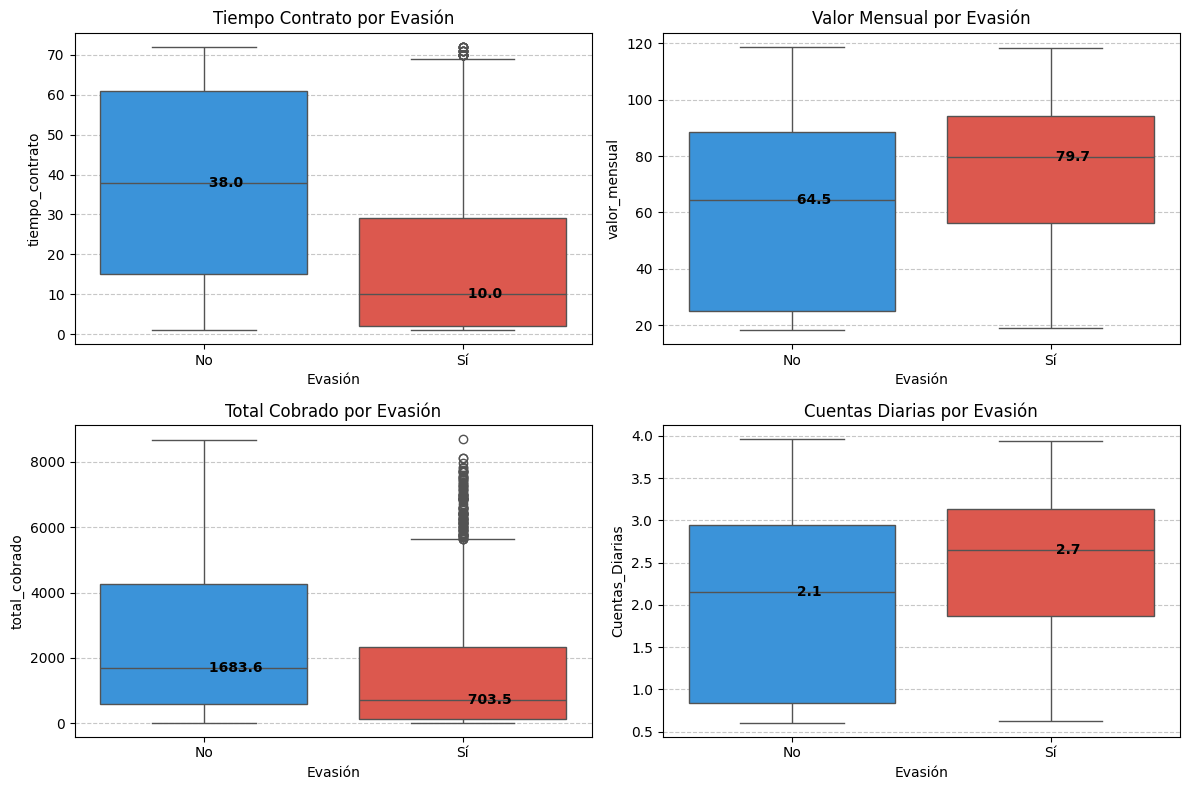

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

numericas = ['tiempo_contrato', 'valor_mensual', 'total_cobrado', 'Cuentas_Diarias']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i],
            hue='Churn', palette={'No': '#2196F3', 'Sí': '#F44336'},
            legend=False)

    # Agregar mediana como texto encima de cada caja
    for j, grupo in enumerate(['No', 'Sí']):
        mediana = df[df['Churn'] == grupo][col].median()
        axes[i].text(j, mediana, f' {mediana:.1f}',
                     va='center', fontweight='bold', fontsize=10)

    axes[i].set_title(f'{col.replace("_", " ").title()} por Evasión')
    axes[i].set_xlabel('Evasión')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#📄Informe final

# 📊 Informe Final: Análisis de Evasión de Clientes - Telecom X

## 1. Introducción

Telecom X enfrenta una alta tasa de cancelaciones de clientes (Churn).
El objetivo de este análisis es identificar los factores que influyen en la
decisión de los clientes de abandonar el servicio, utilizando un dataset de
**7,043 clientes** con 21 variables demográficas, de servicios y de cuenta.

Este análisis forma parte del proceso ETL y EDA previo al desarrollo de
modelos predictivos que permitan anticipar y reducir la evasión.


## 2. Limpieza y Tratamiento de Datos

Los datos fueron extraídos desde una API en formato JSON y procesados con las
siguientes transformaciones:

- ✅ Aplanamiento del JSON anidado con `pd.json_normalize()`
- ✅ Conversión de `account.Charges.Total` de `object` a `float64`
- ✅ Eliminación de 224 registros con valor vacío en la columna `Churn`
- ✅ Eliminación de filas con valores nulos en `Charges.Total`
- ✅ Creación de columna `Cuentas_Diarias` (cargo mensual / 30)
- ✅ Estandarización de valores categóricos al español
- ✅ Renombrado de columnas para mayor claridad

**Dataset final limpio: 7,043 registros | 0 valores nulos | 0 duplicados**


## 3. Análisis Exploratorio y Conclusiones

### Distribución de Evasión
El **26.6% de los clientes** canceló el servicio — dataset desbalanceado
que deberá considerarse en futuros modelos predictivos.

### Hallazgos por variables categóricas
- **Tipo de contrato:** Los clientes con contrato **mensual** tienen una tasa
  de evasión altísima (1,655 cancelaciones) vs contrato anual (166) o bienal (48).
- **Método de pago:** El **cheque electrónico** concentra 1,071 cancelaciones,
  más del triple que otros métodos.
- **Tipo de internet:** Los usuarios de **fibra óptica** evaden más (1,297)
  que los de DSL (459).
- **Género:** Sin diferencia significativa entre Femenino y Masculino.

### Hallazgos por variables numéricas
- Los clientes que se van llevan en promedio **10 meses** de contrato vs
  **38 meses** de los que se quedan.
- Los clientes que evaden pagan en promedio **$79.7/mes** vs **$64.5**
  de los que se quedan — pagan más pero se van antes.




## 4. Recomendaciones Estratégicas

1. ✅**Incentivar contratos anuales o bienales** con descuentos para reducir
   la evasión de clientes mes a mes.
2. ✅**Programa de retención en los primeros 12 meses** — es el período
   crítico donde ocurre la mayor parte de las cancelaciones.
3. ✅**Revisar el precio y calidad del servicio de fibra óptica** —
   tiene alta evasión pese a ser el servicio premium.
4. ✅**Investigar por qué el cheque electrónico está asociado a mayor evasión**
   — podría indicar un perfil de cliente más volátil o problemas en el proceso de pago.
5. ✅**Desarrollar un modelo predictivo de Churn** usando estas variables
   como features principales: tipo_contrato, tiempo_contrato, valor_mensual, tipo_internet.

#¡Extra! Análisis de correlación entre variables

In [156]:
df_corr = df.copy()

# Churn ya es 'Yes'/'No' o 'Sí'/'No' — conviértelo a numérico
df_corr['Churn_num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0, 'Sí': 1})

# tiene +60 ya es 0/1 desde el origen
df_corr['tiene_60_num'] = df_corr['tiene +60'].astype(int)

# Servicios contratados
servicios = ['servicio_telefono', 'seguridad_online', 'backup_online',
             'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas']

df_corr['total_servicios'] = (df_corr[servicios] == 'Sí').sum(axis=1)

In [157]:
cols = ['Churn_num', 'tiempo_contrato', 'valor_mensual',
        'total_cobrado', 'Cuentas_Diarias', 'tiene_60_num', 'total_servicios']

correlacion = df_corr[cols].corr()
print(correlacion['Churn_num'].sort_values(ascending=False))


Churn_num          1.000000
Cuentas_Diarias    0.192858
valor_mensual      0.192858
tiene_60_num       0.150541
total_servicios   -0.086173
total_cobrado     -0.199484
tiempo_contrato   -0.354049
Name: Churn_num, dtype: float64


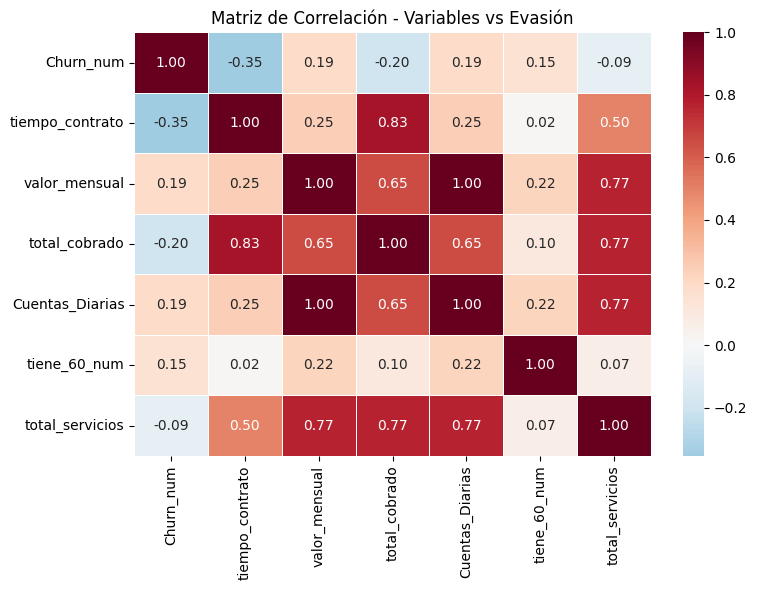

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de Correlación - Variables vs Evasión')
plt.tight_layout()
plt.show()
